In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training on {X_train.shape[0]} rows and {X_train.shape[1]} features.")

Training on 353 rows and 10 features.


In [4]:
# the scikit learn model
lr_sklearn = LinearRegression()
lr_sklearn.fit(X_train, y_train)
y_pred_sklearn = lr_sklearn.predict(X_test)

r2_sklearn = r2_score(y_test, y_pred_sklearn)
mae_sklearn = mean_absolute_error(y_test, y_pred_sklearn)

In [5]:
# my new custom class
class NewMLR:
  def __init__(self):
    self.coef_ = None
    self.intercept_ = None

  def fit(self,X_train, y_train):
    # adding a column of one's in front of the X matrix for the intercept (b0): np.insert(array, index, values, axis)
    X_train_matrix = np.insert(X_train, 0, 1, axis=1)

    # forumula: Beta = (X^T * X)^-1 * X^T * Y
    X_transpose = X_train_matrix.T
    matrix_multiplication = np.dot(X_transpose, X_train_matrix)
    inverse_matrix = np.linalg.inv(matrix_multiplication) # now i got (X^T * X)^-1

    betas = np.dot(np.dot(inverse_matrix, X_transpose), y_train) # final beta

    # the first number is intercept rest are coeffs
    self.intercept_ = betas[0]
    self.coeff_ = betas[1:]

  def predict(self, X_test):
    # y = b0 + (b1 * x1) .....
    return np.dot(X_test, self.coeff_) + self.intercept_


In [7]:
lr_custom = NewMLR()
lr_custom.fit(X_train, y_train)
y_custom_pred = lr_custom.predict(X_test)

r2_custom = r2_score(y_test, y_custom_pred)
mae_custom = mean_absolute_error(y_test, y_custom_pred)

# Finally comparison of the both results my class and scikit class

In [8]:
print("\n--- Model Evaluation ---")
print(f"Scikit-Learn R2: {r2_sklearn:.10f}")
print(f"Custom MLR R2:   {r2_custom:.10f}")
print(f"Scikit-Learn MAE: {mae_sklearn:.10f}")
print(f"Custom MLR MAE:   {mae_custom:.10f}")


--- Model Evaluation ---
Scikit-Learn R2: 0.4526027630
Custom MLR R2:   0.4526027630
Scikit-Learn MAE: 42.7940946796
Custom MLR MAE:   42.7940946796


In [10]:
print("\n--- Internal Weights (The Math) ---")
print(f"Scikit-Learn Intercept: {lr_sklearn.intercept_:.6f}")
print(f"Custom MLR Intercept:   {lr_custom.intercept_:.6f}")
print(f"Feature 1 Weight (Sklearn): {lr_sklearn.coef_[0]:.6f}")
print(f"Feature 1 Weight (Custom):  {lr_custom.coeff_[0]:.6f}")


--- Internal Weights (The Math) ---
Scikit-Learn Intercept: 151.345605
Custom MLR Intercept:   151.345605
Feature 1 Weight (Sklearn): 37.904021
Feature 1 Weight (Custom):  37.904021


In [12]:
print("\nDid the predictions match exactly? ->", np.allclose(y_pred_sklearn, y_custom_pred))


Did the predictions match exactly? -> True


# Visualization of 10 dimesions

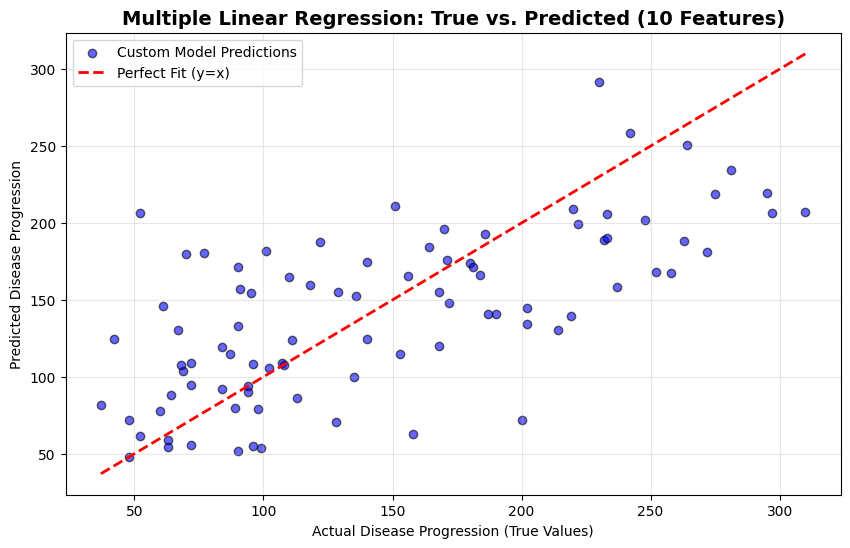


Notice how the points cluster around the red dashed line. The closer they are to the line, the lower the Mean Absolute Error!


In [14]:
plt.figure(figsize=(10, 6))

# Plot the predictions
plt.scatter(y_test, y_custom_pred, color='blue', alpha=0.6, edgecolor='k', label='Custom Model Predictions')

min_val = min(np.min(y_test), np.min(y_custom_pred))
max_val = max(np.max(y_test), np.max(y_custom_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit (y=x)')

plt.title('Multiple Linear Regression: True vs. Predicted (10 Features)', fontsize=14, fontweight='bold')
plt.xlabel('Actual Disease Progression (True Values)')
plt.ylabel('Predicted Disease Progression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nNotice how the points cluster around the red dashed line. The closer they are to the line, the lower the Mean Absolute Error!")